# Hammerstein–Wiener Simulator

This notebook documents `HammersteinWienerSimulator`: a **block-oriented nonlinear**
white-noise-to-target generator, and contrasts it with the linear
`WienerFilterSimulator` already in S2Generator.

## Principle

### Classical Wiener filter (linear)

A classical Wiener filter is an **optimal linear** operator under a mean-square
criterion. In the simulator suite, the practical realization is a Yule–Walker AR
core: white noise $w$ is shaped by a linear filter $G(z)=1/A(z)$ so that the
output matches the target's **second-order** structure (ACF / PSD).

$$
y_{\mathrm{lin}} = G \ast w.
$$

Gaussian $w$ through a linear $G$ stays (approximately) Gaussian: **skewness /
heavy tails / asymmetric amplitude laws cannot be reproduced** even when the
spectrum looks right.

### Hammerstein–Wiener (HW) blocks

$$
w \;\xrightarrow{\;f(\cdot)\;}\; u
\;\xrightarrow{\;G(z)\;}\; v
\;\xrightarrow{\;g(\cdot)\;}\; y
$$

| Block | Role |
| --- | --- |
| $f$ (Hammerstein) | Static input nonlinearity: shapes the innovation law |
| $G$ | Same linear AR / Wiener core (ACF / PSD) |
| $g$ (Wiener nonlinear) | Static output nonlinearity: shapes the amplitude CDF |

In this implementation, $f$ and $g$ are **monotone quantile maps** (PCHIP on
QQ knots). Polynomial coefficients of those knots are also stored for inspection.

### Fit stages

1. **ReVIN** (optional): z-score the target.
2. **$G$**: Yule–Walker on the target ACF (identical idea to `WienerFilterSimulator`).
3. **$f$**: map $\mathcal{N}(0,1)$ quantiles → AR-residual quantiles; scale to $\sigma^2$.
4. **$g$**: map quantiles of $G(f(w))$ → quantiles of the target.
5. Optional low-pass post-process on `transform` outputs.

In [1]:
import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.stattools import acf

sys.path.insert(0, os.path.abspath("../.."))
warnings.filterwarnings("ignore")

from s2generator.simulator import HammersteinWienerSimulator, WienerFilterSimulator
from s2generator.simulator.hammerstein_wiener_filter import apply_static_map

plt.rcParams.update(
    {"figure.figsize": (12, 3.8), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11}
)
print("ready")

ready


## Helpers

In [2]:
def make_nonlinear_target(n=1000, seed=2):
    rng = np.random.RandomState(seed)
    e = rng.normal(0.0, 1.0, size=n + 50)
    z = signal.lfilter([1.0], [1.0, -0.6, 0.25], e)[50:]
    z = (z - z.mean()) / (z.std() + 1e-12)
    return np.tanh(z) + 0.55 * z + 0.35 * (z**2) / (1.0 + z**2)


def skew(x):
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x - x.mean()
    s = x.std()
    return 0.0 if s < 1e-12 else float(np.mean((x / s) ** 3))


def kurtosis(x):
    x = np.asarray(x, dtype=np.float64).ravel()
    x = x - x.mean()
    s = x.std()
    return 0.0 if s < 1e-12 else float(np.mean((x / s) ** 4))


def wasserstein1(a, b, n=512):
    a = np.sort(np.asarray(a, float).ravel())
    b = np.sort(np.asarray(b, float).ravel())
    qa = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(a)), a)
    qb = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(b)), b)
    return float(np.mean(np.abs(qa - qb)))


def onesided_psd(x):
    x = np.asarray(x, float)
    x = x - x.mean()
    return np.fft.rfftfreq(len(x)), np.abs(np.fft.rfft(x)) ** 2

## 1. Nonlinear target the linear Wiener struggles with

target skew=0.325, kurtosis=2.194, std=1.168


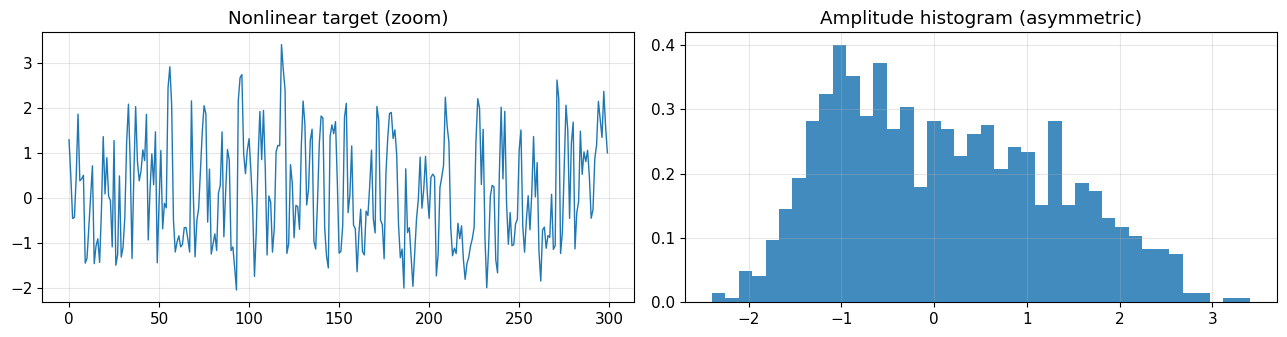

In [3]:
target = make_nonlinear_target(1000, seed=2)
print(f"target skew={skew(target):.3f}, kurtosis={kurtosis(target):.3f}, std={target.std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(target[:300], lw=1.0)
axes[0].set_title("Nonlinear target (zoom)")
axes[1].hist(target, bins=40, density=True, alpha=0.85, color="C0")
axes[1].set_title("Amplitude histogram (asymmetric)")
fig.tight_layout()
plt.show()

## 2. Fit HW and inspect internal blocks

AR coeffs G: [ 1.     -0.5747  0.2418  0.0549 -0.0075 -0.006 ]
sigma_sq: 0.7259
input poly summary f: [ 0.0049  0.9067  0.0338 -0.0128]
output poly summary g: [-0.0951  1.0903  0.0528 -0.037 ]


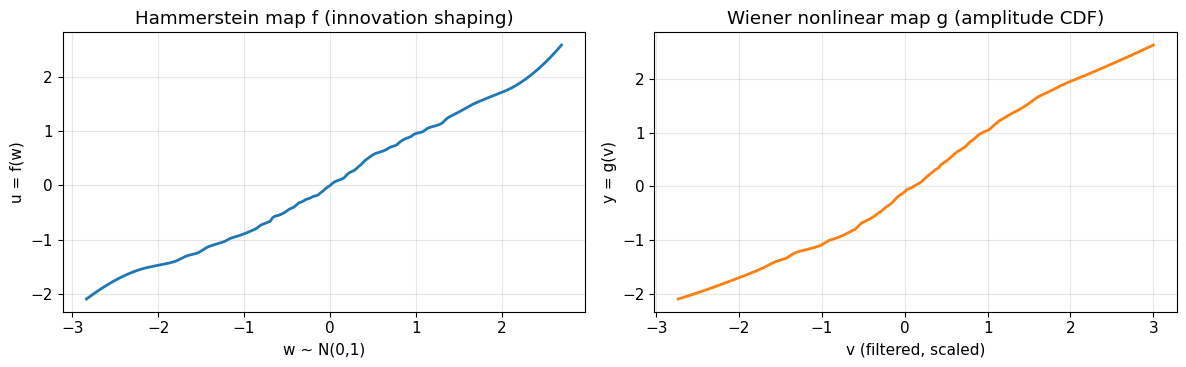

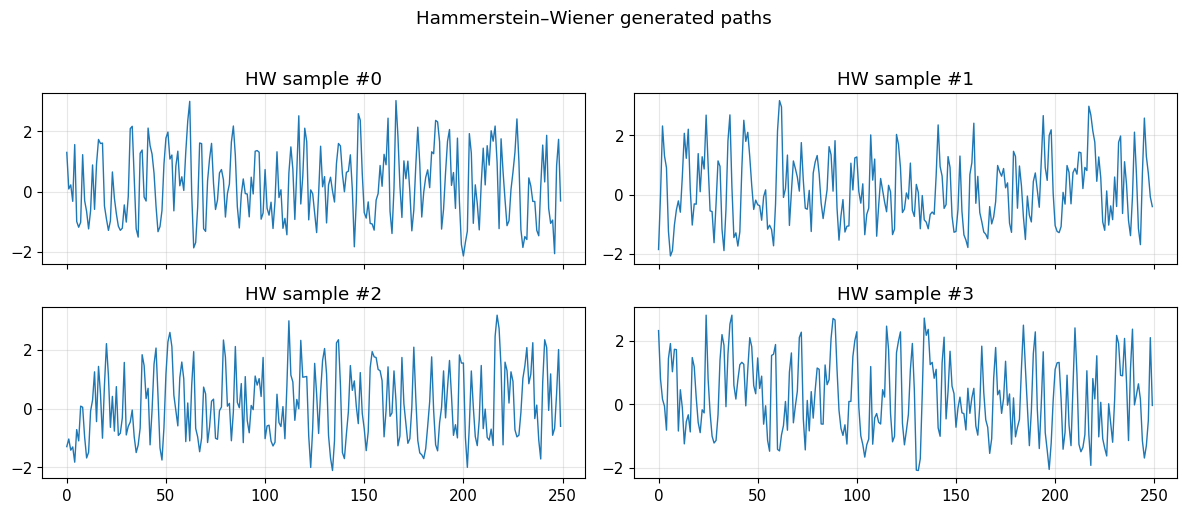

In [4]:
hw = HammersteinWienerSimulator(
    filter_order=6, input_degree=3, output_degree=3, random_state=0
)
hw.fit(target)

print("AR coeffs G:", np.round(hw.coeffs, 4))
print("sigma_sq:", round(hw.sigma_sq, 4))
print("input poly summary f:", np.round(hw.input_coeffs, 4))
print("output poly summary g:", np.round(hw.output_coeffs, 4))

xg = np.linspace(hw._input_xq.min(), hw._input_xq.max(), 200)
xv = np.linspace(hw._output_xq.min(), hw._output_xq.max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(xg, apply_static_map(xg, hw._input_xq, hw._input_yq), lw=2)
axes[0].set_title("Hammerstein map f (innovation shaping)")
axes[0].set_xlabel("w ~ N(0,1)")
axes[0].set_ylabel("u = f(w)")
axes[1].plot(xv, apply_static_map(xv, hw._output_xq, hw._output_yq), lw=2, color="C1")
axes[1].set_title("Wiener nonlinear map g (amplitude CDF)")
axes[1].set_xlabel("v (filtered, scaled)")
axes[1].set_ylabel("y = g(v)")
fig.tight_layout()
plt.show()

y_hw = hw.transform(num_samples=4, seq_length=len(target), random_state=1)
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
for ax, i in zip(axes.ravel(), range(4)):
    ax.plot(y_hw[i, :250], lw=1.0)
    ax.set_title(f"HW sample #{i}")
fig.suptitle("Hammerstein–Wiener generated paths", y=1.02)
fig.tight_layout()
plt.show()

## 3. Head-to-head vs linear WienerFilterSimulator

Same target, same filter order / seed. Compare paths, spectra, histograms, and scalar metrics.

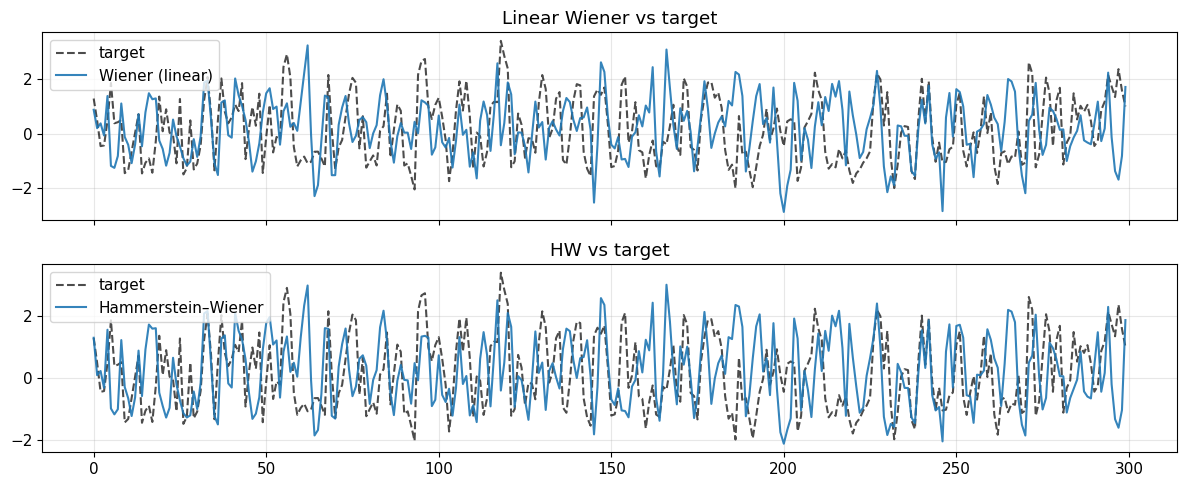

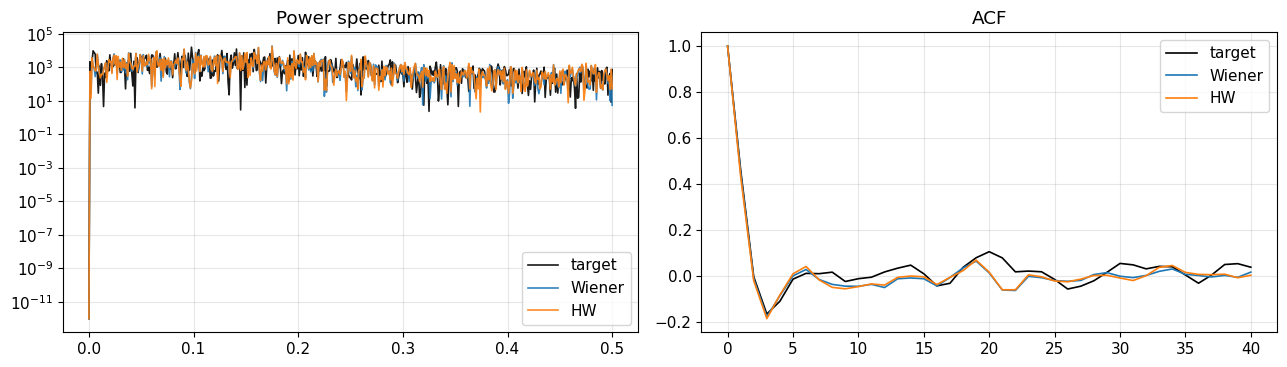

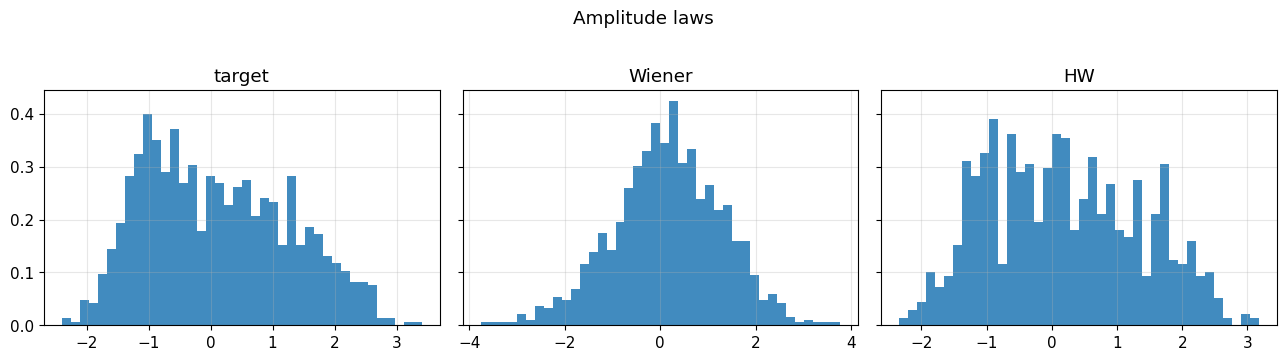

In [5]:
wiener = WienerFilterSimulator(filter_order=6, random_state=0)
wiener.fit(target)

y_w = wiener.transform(num_samples=4, seq_length=len(target), random_state=1)
y_hw = hw.transform(num_samples=4, seq_length=len(target), random_state=1)

# Time overlays
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(target[:300], "k--", alpha=0.7, label="target")
axes[0].plot(y_w[0, :300], alpha=0.9, label="Wiener (linear)")
axes[0].legend()
axes[0].set_title("Linear Wiener vs target")
axes[1].plot(target[:300], "k--", alpha=0.7, label="target")
axes[1].plot(y_hw[0, :300], alpha=0.9, label="Hammerstein–Wiener")
axes[1].legend()
axes[1].set_title("HW vs target")
fig.tight_layout()
plt.show()

# Spectrum + ACF
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for name, series, c in [
    ("target", target, "k"),
    ("Wiener", y_w[0], "C0"),
    ("HW", y_hw[0], "C1"),
]:
    f, p = onesided_psd(series)
    axes[0].semilogy(f, p + 1e-12, label=name, lw=1.2, color=c, alpha=0.9)
    axes[1].plot(acf(series, nlags=40, fft=True), label=name, lw=1.2, color=c)
axes[0].set_title("Power spectrum")
axes[0].legend()
axes[1].set_title("ACF")
axes[1].legend()
fig.tight_layout()
plt.show()

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, series, title in [
    (axes[0], target, "target"),
    (axes[1], y_w[0], "Wiener"),
    (axes[2], y_hw[0], "HW"),
]:
    ax.hist(series, bins=40, density=True, alpha=0.85)
    ax.set_title(title)
fig.suptitle("Amplitude laws", y=1.02)
fig.tight_layout()
plt.show()

In [6]:
rows = []
for name, samples in [("Wiener", y_w), ("HW", y_hw)]:
    w1 = np.mean([wasserstein1(target, samples[i]) for i in range(samples.shape[0])])
    skew_err = np.mean([abs(skew(samples[i]) - skew(target)) for i in range(samples.shape[0])])
    kurt_err = np.mean([abs(kurtosis(samples[i]) - kurtosis(target)) for i in range(samples.shape[0])])
    rows.append((name, w1, skew_err, kurt_err))

print(f"{'model':8s} | {'W1 dist':>10s} | {'|Δskew|':>10s} | {'|Δkurt|':>10s}")
print("-" * 48)
for name, w1, se, ke in rows:
    print(f"{name:8s} | {w1:10.4f} | {se:10.4f} | {ke:10.4f}")

print("\nInterpretation:")
print("- Spectrum/ACF: both models track second-order structure via G.")
print("- Amplitude law (W1 / skew / kurtosis): HW should be closer because of f and g.")

model    |    W1 dist |    |Δskew| |    |Δkurt|
------------------------------------------------
Wiener   |     0.1644 |     0.2742 |     0.8810
HW       |     0.0497 |     0.0538 |     0.0412

Interpretation:
- Spectrum/ACF: both models track second-order structure via G.
- Amplitude law (W1 / skew / kurtosis): HW should be closer because of f and g.


## 4. Usage

```python
from s2generator.simulator import HammersteinWienerSimulator
import numpy as np

sim = HammersteinWienerSimulator(filter_order=6, random_state=0)
sim.fit(target)
y = sim.transform(num_samples=8, seq_length=len(target), random_state=1)
```

When the target is nearly Gaussian and linear, HW collapses toward the linear
Wiener behavior ($f$ and $g$ ≈ identity). Its advantage appears on **nonlinear /
asymmetric** amplitude structure.